# Used Car Price Prediction - Regression Models

**Epochs '26 - Assignment 5**

Dataset: CarDekho Used Car Dataset (Kaggle)

Goal of this notebook: predict the selling price of used cars using a few different regression models, compare how they do, and pick the best one.

## Part 1: Problem Understanding

**Business objective:** CarDekho is an online platform where people buy and sell used cars. When someone lists their car, they need some idea of what price to set - too high and no one buys it, too low and they lose money. So the goal here is to build a model that can look at a car's details (brand, age, km driven, fuel type, etc.) and predict a fair selling price.

**Target variable:** `selling_price` (this is what we're trying to predict, it's continuous so this is a regression problem)

**Features:**
- Numerical: `vehicle_age`, `km_driven`, `mileage`, `engine`, `max_power`, `seats`
- Categorical: `brand`, `model`, `seller_type`, `fuel_type`, `transmission_type`

Basically we're trying to find the relationship between how old/used/powerful a car is and what it actually sells for.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('darkgrid')
%matplotlib inline

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('cardekho_dataset.csv')
print(df.shape)
df.head()

(15411, 14)


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [3]:
# there's an extra unnamed index column from when this was exported, don't need it
df = df.drop(columns=['Unnamed: 0'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  str    
 1   brand              15411 non-null  str    
 2   model              15411 non-null  str    
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  str    
 6   fuel_type          15411 non-null  str    
 7   transmission_type  15411 non-null  str    
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), str(6)
memory usage: 1.5 MB


In [4]:
df.isnull().sum()

car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Good, no missing values so we don't have to worry about imputing anything.

In [5]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


A couple of things stand out already:
- `selling_price` has a huge range (40,000 to almost 4 crore) and the mean is way higher than the median, so the distribution is right-skewed - there are some very expensive cars pulling the average up.
- `vehicle_age` goes up to 29 years which is pretty old for a "used car" listing but not impossible.

Let's look at the target variable distribution.

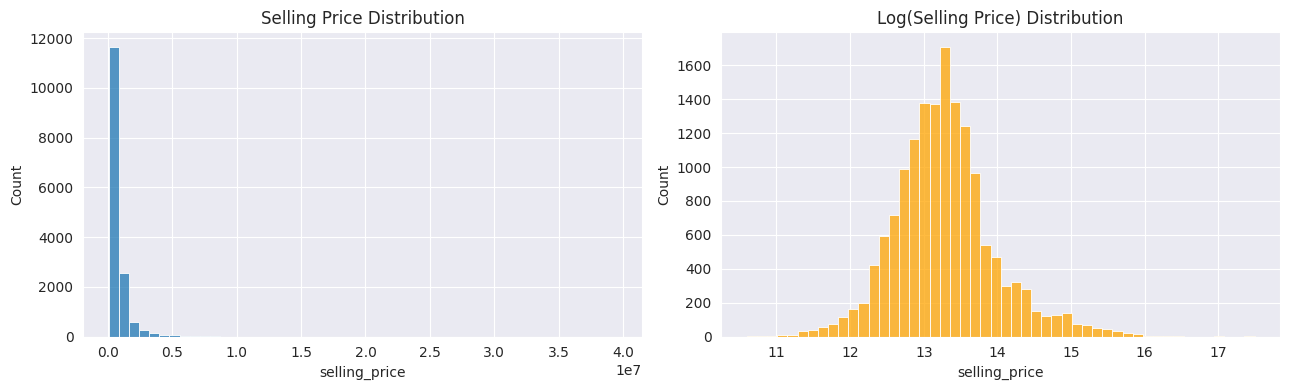

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['selling_price'], bins=50, ax=axes[0])
axes[0].set_title('Selling Price Distribution')

sns.histplot(np.log1p(df['selling_price']), bins=50, ax=axes[1], color='orange')
axes[1].set_title('Log(Selling Price) Distribution')
plt.tight_layout()
plt.show()

Yeah, `selling_price` is heavily right-skewed - lots of cars in the lower price range and a long tail of expensive ones. The log-transformed version looks a lot closer to normal. We'll keep this in mind - it's one reason Linear Regression might struggle a bit compared to tree-based models which don't care about skew as much.

Let's also check how many unique values the categorical columns have, since that affects how we encode them.

In [7]:
for col in ['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']:
    print(col, '->', df[col].nunique(), 'unique values')

brand -> 32 unique values
model -> 120 unique values
seller_type -> 3 unique values
fuel_type -> 5 unique values
transmission_type -> 2 unique values


`model` has way too many unique values (around 120) to one-hot encode without blowing up the number of columns, and `car_name` is basically the same info as brand + model combined. So we'll drop `car_name` and `model`, and just keep `brand` which still captures most of the useful signal (32 categories is manageable).

In [8]:
df = df.drop(columns=['car_name', 'model'])
df.columns.tolist()

['brand',
 'vehicle_age',
 'km_driven',
 'seller_type',
 'fuel_type',
 'transmission_type',
 'mileage',
 'engine',
 'max_power',
 'seats',
 'selling_price']

## Part 2: Data Preparation

Steps here:
1. Handle outliers in `selling_price` a bit (there are a few extreme luxury car listings that could throw off the models)
2. Encode the categorical columns
3. Split into train/test
4. Scale the numeric features

**No missing values** to handle as we saw above, so that part's easy.

In [9]:
# checking for extreme outliers using IQR
Q1 = df['selling_price'].quantile(0.25)
Q3 = df['selling_price'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR
print('Upper bound:', upper_bound)
print('Rows above bound:', (df['selling_price'] > upper_bound).sum(), 'out of', len(df))

Upper bound: 2145000.0
Rows above bound: 732 out of 15411


In [10]:
# these are mostly legit luxury cars (Audi, BMW, Land Rover etc), not data errors,
# but they're rare enough that they can skew the model a lot. dropping the most extreme ones
df = df[df['selling_price'] <= upper_bound].reset_index(drop=True)
print(df.shape)

(14679, 11)


Now let's encode the categorical features. Using one-hot encoding since none of these categories have a natural order (fuel type, seller type etc aren't ranked).

In [11]:
cat_cols = ['brand', 'seller_type', 'fuel_type', 'transmission_type']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(df_encoded.shape)
df_encoded.head()

(14679, 39)


,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,brand_BMW,brand_Datsun,brand_Force,brand_Ford,brand_Honda,brand_Hyundai,brand_ISUZU,brand_Isuzu,brand_Jaguar,brand_Jeep,brand_Kia,brand_Land Rover,brand_MG,brand_Mahindra,brand_Maruti,brand_Mercedes-Benz,brand_Mini,brand_Nissan,brand_Porsche,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,120000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True
1,5,20000,18.90,1197,82.00,5,550000,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True
2,11,60000,17.00,1197,80.00,5,215000,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True
3,9,37000,20.92,998,67.10,5,226000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,True
4,6,30000,22.77,1498,98.59,5,570000,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True


In [12]:
X = df_encoded.drop(columns=['selling_price'])
y = df_encoded['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train size:', X_train.shape, 'Test size:', X_test.shape)

Train size: (11743, 38) Test size: (2936, 38)


**Feature scaling:** Linear Regression is sensitive to features being on very different scales (e.g. `km_driven` is in the hundred-thousands while `seats` is a single digit), so we scale for that. Tree-based models like Decision Tree and Random Forest split on feature thresholds directly and aren't affected by scale, but scaling doesn't hurt them either, so we'll just use the scaled version for all three models to keep things consistent.

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# scikit-learn returns numpy arrays, converting back to DataFrame just so it's easier to inspect
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

## Part 3: Model Development

Training three regression models:
1. Linear Regression - simple baseline
2. Decision Tree Regressor
3. Random Forest Regressor

In [14]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

In [15]:
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train_scaled, y_train)
dt_preds = dt.predict(X_test_scaled)

In [16]:
rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)

(set a max_depth on the tree models so they don't just overfit like crazy and memorize the training set)

## Part 4: Model Evaluation & Comparison

In [17]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

results = {}
results['Linear Regression'] = evaluate(y_test, lr_preds)
results['Decision Tree'] = evaluate(y_test, dt_preds)
results['Random Forest'] = evaluate(y_test, rf_preds)

comparison_df = pd.DataFrame(results, index=['MAE', 'MSE', 'RMSE', 'R2 Score']).T
comparison_df

,MAE,MSE,RMSE,R2 Score
Linear Regression,115168.482511,2.698927e+10,164284.098939,0.804112
Decision Tree,85085.958793,1.731764e+10,131596.493865,0.874309
Random Forest,74884.686516,1.264330e+10,112442.415020,0.908235


/tmp/ipykernel_566/3097538660.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison_df.index, y=comparison_df['R2 Score'], palette='viridis')


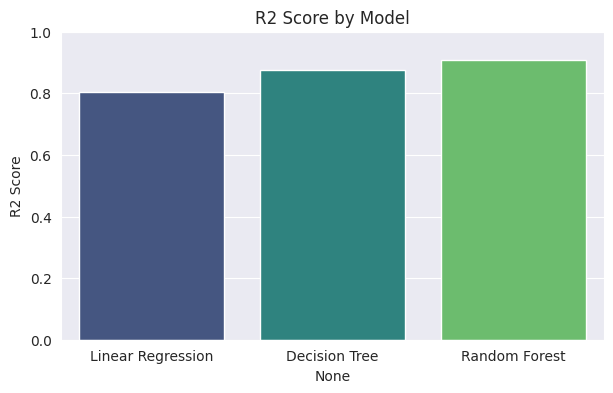

In [18]:
plt.figure(figsize=(7,4))
sns.barplot(x=comparison_df.index, y=comparison_df['R2 Score'], palette='viridis')
plt.title('R2 Score by Model')
plt.ylabel('R2 Score')
plt.ylim(0, 1)
plt.show()

/tmp/ipykernel_566/3359112183.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison_df.index, y=comparison_df['RMSE'], palette='mako')


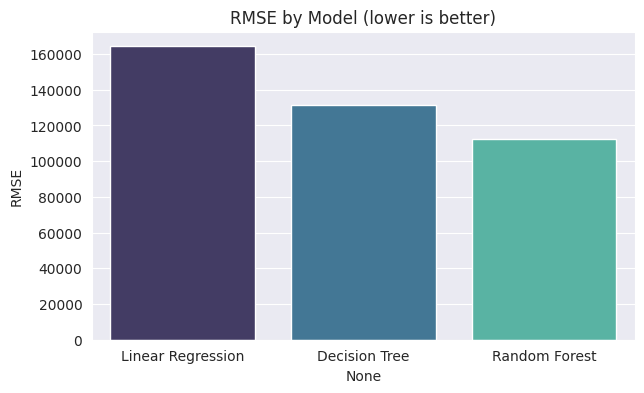

In [19]:
plt.figure(figsize=(7,4))
sns.barplot(x=comparison_df.index, y=comparison_df['RMSE'], palette='mako')
plt.title('RMSE by Model (lower is better)')
plt.ylabel('RMSE')
plt.show()

Random Forest comes out on top with the highest R² and lowest RMSE/MAE. This makes sense - it's an ensemble of many decision trees averaged together, so it captures the non-linear relationships in the data (like how price doesn't drop *linearly* with age, or how brand + engine size interact) way better than a single Linear Regression line can. It's also more stable than a single Decision Tree because averaging many trees reduces overfitting/variance.

Decision Tree does reasonably okay but noticeably worse than Random Forest - a single tree tends to overfit to specific patterns in the training data that don't generalize as well.

Linear Regression performs the worst of the three here, most likely because the relationship between car age/km driven and price isn't actually linear (price tends to drop off fast for the first few years, then level out) and linear regression can't capture that curve.

/tmp/ipykernel_566/2348897272.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='crest')


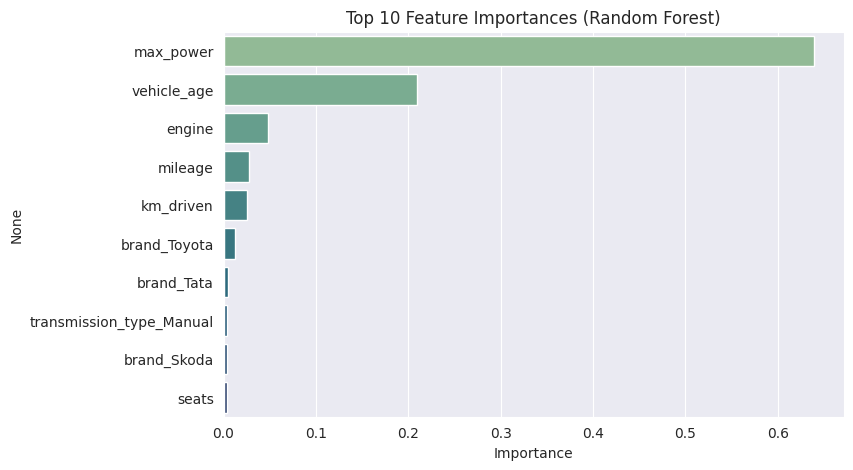

In [20]:
# quick look at what features Random Forest thinks matter most
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, palette='crest')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.show()

Not too surprising - `max_power`, `engine`, `vehicle_age` and `km_driven` are the biggest drivers of price, which lines up with how people actually think about buying a used car in real life.

### Strengths & Limitations

- **Linear Regression** - fast, easy to interpret (you can literally read off the coefficients), but assumes a straight-line relationship which doesn't hold well here. Weakest performer.
- **Decision Tree** - can capture non-linear patterns, easy to visualize, but prone to overfitting on training data if not depth-limited.
- **Random Forest** - best performer here, handles non-linearity and reduces overfitting by averaging many trees, but it's slower to train and harder to interpret than a single tree (kind of a black box).

### Possible Improvements

1. **Hyperparameter tuning** - use GridSearchCV / RandomizedSearchCV to properly tune `n_estimators`, `max_depth`, `min_samples_split` etc. for Random Forest instead of the values picked here somewhat manually.
2. **Try gradient boosting models** - XGBoost or LightGBM usually outperform Random Forest on tabular data like this and could push the R² even higher.
3. **Better handling of the `model` column** - instead of dropping it entirely, could try target encoding or grouping rare car models into an "Other" bucket to keep some of that signal without exploding the feature count.
4. **Log-transform the target** - since selling_price is right-skewed, training on log(selling_price) and then converting predictions back might help Linear Regression especially.

## Conclusion

Out of the three models tested, **Random Forest Regressor** gave the best results with the highest R² score and lowest error metrics, making it the most reliable choice for predicting used car prices on this dataset. Linear Regression struggled the most since the underlying price relationship isn't linear. With some hyperparameter tuning and maybe trying a boosting model, the results could likely be pushed even further.